In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import xgboost as xgb
import matplotlib.pyplot as plt

In [2]:
df = pd.read_parquet("/Users/kevineriksson/PycharmProjects/MLOps/green_tripdata_2021-01.parquet", engine="pyarrow")
df = df[
    (df["trip_distance"] > 0) &
    (df["trip_distance"] < 100)  # even 200 miles is extremely generous
]

In [70]:
bins = [0, 5, 12, 17, 21]
labels = ["Night", "Morning", "Afternoon", "Evening"]

df["pickup_time_period"] = pd.cut(
    df["lpep_pickup_datetime"].dt.hour,
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True
)

df["dropoff_time_period"] = pd.cut(
    df["lpep_dropoff_datetime"].dt.hour,
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True
)

In [71]:
from sklearn.metrics import mean_absolute_error

df = df.copy()

# --- Create duration target ---
df["lpep_pickup_datetime"] = pd.to_datetime(df["lpep_pickup_datetime"])
df["lpep_dropoff_datetime"] = pd.to_datetime(df["lpep_dropoff_datetime"])

df["trip_duration_min"] = (
    df["lpep_dropoff_datetime"] - df["lpep_pickup_datetime"]
).dt.total_seconds() / 60

# Remove broken trips
df = df[(df["trip_duration_min"] > 0) & (df["trip_duration_min"] < 180)]

# --- Feature engineering ---
df["pickup_hour"] = df["lpep_pickup_datetime"].dt.hour
df["pickup_dow"] = df["lpep_pickup_datetime"].dt.dayofweek
df["pickup_month"] = df["lpep_pickup_datetime"].dt.month
df["is_weekend"] = df["pickup_dow"].isin([5,6]).astype(int)

# --- Define features ---
features = [
    "PULocationID",
    "DOLocationID",
    "pickup_hour",
    "pickup_dow",
    "pickup_month",
    "is_weekend",
    "passenger_count"
]

X = df[features]
y = df["trip_duration_min"]

# One-hot encode categorical zone IDs
X = pd.get_dummies(X, columns=["PULocationID", "DOLocationID"], drop_first=False)

# --- Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- Train model ---
model_duration = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=50
)

model_duration.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1500,
             n_jobs=None, num_parallel_tree=None, ...)

In [65]:
# --- Evaluate ---
pred = model_duration.predict(X_test)

mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, pred)

print("Duration RMSE (min):", rmse)
print("Duration MAE (min):", mae)

Duration RMSE (min): 9.915767640186868
Duration MAE (min): 6.420784871064855


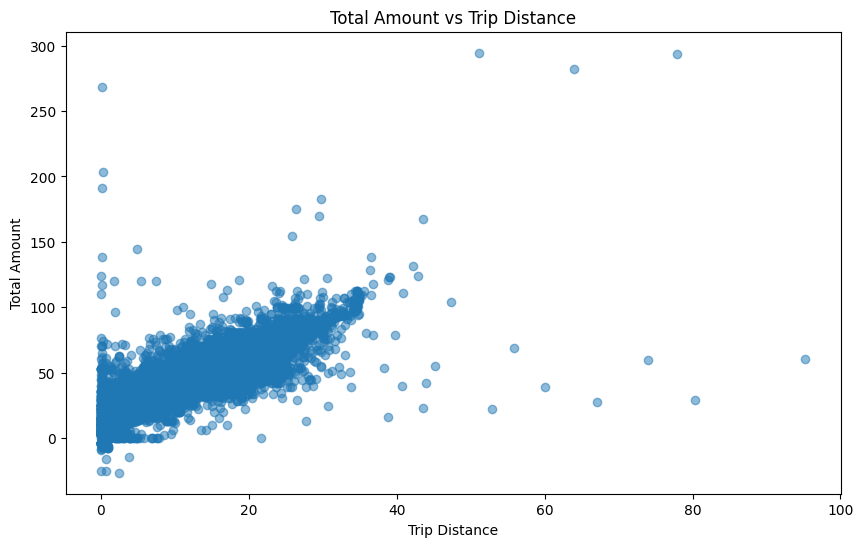

In [73]:
plt.figure(figsize=(10, 6))
plt.scatter(df['trip_distance'], df['total_amount'], alpha=0.5)
plt.title('Total Amount vs Trip Distance')
plt.xlabel('Trip Distance')
plt.ylabel('Total Amount')
plt.show()


In [75]:
from sklearn.model_selection import KFold

df = df.copy()

# --------------------------
# 0) Parse times + targets
# --------------------------
df["lpep_pickup_datetime"] = pd.to_datetime(df["lpep_pickup_datetime"], errors="coerce")
df["lpep_dropoff_datetime"] = pd.to_datetime(df["lpep_dropoff_datetime"], errors="coerce")

# Duration target (minutes) ONLY for training duration model
df["trip_duration_min"] = (df["lpep_dropoff_datetime"] - df["lpep_pickup_datetime"]).dt.total_seconds() / 60.0

# Filter bad rows
df = df[df["fare_amount"].notna()]
df = df[(df["trip_duration_min"] > 0) & (df["trip_duration_min"] < 180)]
df = df[df["fare_amount"] > 0]
df = df[df["fare_amount"] < df["fare_amount"].quantile(0.999)]

# --------------------------
# 1) Booking-time features
# --------------------------
df["pickup_hour"] = df["lpep_pickup_datetime"].dt.hour
df["pickup_dow"] = df["lpep_pickup_datetime"].dt.dayofweek
df["pickup_month"] = df["lpep_pickup_datetime"].dt.month
df["is_weekend"] = df["pickup_dow"].isin([5, 6]).astype(int)

# Columns that are leakage for booking-time fare prediction (post-trip money/outcomes)
leak_cols = [
    "lpep_dropoff_datetime",
    "trip_duration_min",          # actual duration (leakage for booking-time)
    "total_amount",
    "tip_amount",
    "tolls_amount",
    "extra",
    "mta_tax",
    "improvement_surcharge",
    "congestion_surcharge",
    "cbd_congestion_fee",
    "payment_type",
]

# Keep only columns that exist
leak_cols = [c for c in leak_cols if c in df.columns]

# Base booking-time features you can use
base_features = [
    "PULocationID",
    "DOLocationID",
    "pickup_hour",
    "pickup_dow",
    "pickup_month",
    "is_weekend",
    "passenger_count",
    "RatecodeID",
    "trip_type",
    "VendorID",
    "store_and_fwd_flag",
]
base_features = [c for c in base_features if c in df.columns]

# Clean store_and_fwd_flag if present
if "store_and_fwd_flag" in df.columns:
    df["store_and_fwd_flag"] = df["store_and_fwd_flag"].fillna("N").astype(str)

# --------------------------
# 2) Train duration model with OOF predictions
# --------------------------
X_dur = df[base_features].copy()
y_dur = df["trip_duration_min"].copy()

# One-hot encode booking-time categoricals
X_dur = pd.get_dummies(X_dur, columns=X_dur.select_dtypes(include=["object", "category"]).columns, dummy_na=True)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_dur_pred = np.zeros(len(df), dtype=float)

dur_params = dict(
    objective="reg:squarederror",
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)

for train_idx, val_idx in kf.split(X_dur):
    X_tr, X_va = X_dur.iloc[train_idx], X_dur.iloc[val_idx]
    y_tr, y_va = y_dur.iloc[train_idx], y_dur.iloc[val_idx]

    m = xgb.XGBRegressor(**dur_params, early_stopping_rounds=50)
    m.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
    oof_dur_pred[val_idx] = m.predict(X_va)

# Fit final duration model on full data (for future inference)
model_duration_final = xgb.XGBRegressor(**dur_params)
model_duration_final.fit(X_dur, y_dur)

# --------------------------
# 3) Train fare model using OOF duration prediction
# --------------------------
df["est_duration_min"] = oof_dur_pred  # SAFE: predicted duration, not actual

# Fare target
y_fare = df["fare_amount"].copy()

# Fare features = booking-time + predicted duration
X_fare = df[base_features + ["est_duration_min"]].copy()
X_fare = pd.get_dummies(X_fare, columns=X_fare.select_dtypes(include=["object", "category"]).columns, dummy_na=True)

# Train/test split for reporting
X_train, X_test, y_train, y_test = train_test_split(X_fare, y_fare, test_size=0.2, random_state=42)

fare_model = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=3000,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=50,
)

fare_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

pred = fare_model.predict(X_test)

mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, pred)

print("Fare RMSE ($):", rmse)
print("Fare MAE  ($):", mae)

Fare RMSE ($): 8.201059995531109
Fare MAE  ($): 4.961598820212714


In [3]:
df = df.copy()

fare_threshold = df["fare_amount"].quantile(0.75)
df["is_high_fare"] = (df["fare_amount"] > fare_threshold).astype(int)

print("High fare threshold:", fare_threshold)
print(df["is_high_fare"].value_counts(normalize=True))

High fare threshold: 25.5
is_high_fare
0    0.750007
1    0.249993
Name: proportion, dtype: float64


In [4]:
leak_cols = [
    "fare_amount",
    "total_amount",
    "tip_amount",
    "tolls_amount",
    "extra",
    "mta_tax",
    "improvement_surcharge",
    "congestion_surcharge",
    "cbd_congestion_fee",
    "payment_type",
    "lpep_dropoff_datetime",
    "trip_duration_min"
]

leak_cols = [c for c in leak_cols if c in df.columns]

In [5]:
df["lpep_pickup_datetime"] = pd.to_datetime(df["lpep_pickup_datetime"])

df["pickup_hour"] = df["lpep_pickup_datetime"].dt.hour
df["pickup_dow"] = df["lpep_pickup_datetime"].dt.dayofweek
df["pickup_month"] = df["lpep_pickup_datetime"].dt.month
df["is_weekend"] = df["pickup_dow"].isin([5,6]).astype(int)

In [6]:
features = [
    "PULocationID",
    "DOLocationID",
    "pickup_hour",
    "pickup_dow",
    "pickup_month",
    "is_weekend",
    "passenger_count",
    "RatecodeID",
    "trip_type",
    "VendorID"
]

features = [c for c in features if c in df.columns]

X = df[features]
y = df["is_high_fare"]

In [7]:
X = pd.get_dummies(
    X,
    columns=X.select_dtypes(include=["object", "category"]).columns,
    dummy_na=True
)

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
import xgboost as xgb

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = xgb.XGBClassifier(
    objective="binary:logistic",
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=50
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

proba = model.predict_proba(X_test)[:,1]
pred = (proba > 0.5).astype(int)

print("ROC AUC:", roc_auc_score(y_test, proba))
print(classification_report(y_test, pred))

ROC AUC: 0.9285439040126415
              precision    recall  f1-score   support

           0       0.89      0.95      0.92     11035
           1       0.82      0.67      0.74      3746

    accuracy                           0.88     14781
   macro avg       0.86      0.81      0.83     14781
weighted avg       0.88      0.88      0.87     14781

